In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
shark_attack_clean_df = pd.read_excel("shark_attack_clean.xlsx")

In [11]:
shark_attack_clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4732 entries, 0 to 4731
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            4732 non-null   datetime64[us]
 1   Year            4732 non-null   int64         
 2   Type            4732 non-null   str           
 3   Country         4732 non-null   str           
 4   Activity        4732 non-null   str           
 5   Sex             4732 non-null   str           
 6   Injury          4711 non-null   str           
 7   Fatal Y/N       4732 non-null   str           
 8   specie          3078 non-null   str           
 9   Date_parsed     4437 non-null   datetime64[us]
 10  Date_Year       4732 non-null   int64         
 11  Activity_Group  4732 non-null   str           
 12  Contains_Fatal  4732 non-null   bool          
 13  shark_name      4732 non-null   str           
dtypes: bool(1), datetime64[us](2), int64(2), str(9)
memory usage: 931.1

In [23]:
#calculate the total number of "Provoked" shark attacks and determine the percentage of these attacks relative to all types of shark attacks
total_provoked_attacks = (
    shark_attack_clean_df["Type"] == "Provoked"
).sum()

total_types = shark_attack_clean_df["Type"].count()

percentual_provoked_attacks = (
    total_provoked_attacks / total_types * 100
)

print(total_provoked_attacks)
print(f"Is {percentual_provoked_attacks:.2f}% of all attacks")

427
Is 9.02% of all attacks


In [24]:
#provoked shark attacks specifically related to the "Fishing" activity group.
total_provoked_attacks = (
    (shark_attack_clean_df["Type"] == "Provoked")&
    (shark_attack_clean_df["Activity_Group"] == "Fishing")
).sum()

total_types = shark_attack_clean_df["Type"].count()

percentual_provoked_attacks = (
    total_provoked_attacks / total_types * 100
)

print(f"Atacked {total_provoked_attacks}")
print(f"Is {percentual_provoked_attacks:.2f}% of all attacks")

Atacked 242
Is 5.11% of all attacks


In [25]:
#filtering for provoked shark attacks that occur during fishing activities and then grouping the results by year
def provoked_fishing_by_year(df):
    return (
        df[
            (df["Type"] == "Provoked") &
            (df["Activity_Group"] == "Fishing")
        ]
        .groupby("Year")
        .size()
        .sort_index()
    )

In [26]:
provoked_per_year = provoked_fishing_by_year(shark_attack_clean_df)

print(provoked_per_year)

Year
1960    12
1961    15
1962     9
1963     9
1964     1
1965     3
1966     7
1967     5
1969     3
1970     2
1971     1
1973     1
1975     2
1976     4
1977     1
1978     1
1979     3
1980     3
1981     1
1982     1
1983     2
1984     3
1985     5
1987     2
1988     1
1989     5
1990     2
1991     3
1993     1
1994     1
1995     1
1996     1
1998     2
1999     1
2001     3
2002     4
2003     2
2004     1
2005     5
2006     4
2007     5
2008     5
2009    10
2010     6
2011     6
2012     5
2013     5
2014     9
2015     5
2016     8
2017     4
2018     6
2019     7
2020     3
2021     6
2022     9
2023     6
2024     2
2025     2
dtype: int64


In [27]:
top_15 = (
    shark_attack_clean_df[
        (shark_attack_clean_df["Type"] == "Provoked")&
        (shark_attack_clean_df["Activity_Group"] == "Fishing")
    ]
    .groupby(["Year", "Activity_Group"])
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="Count")
)

top_15

,Year,Activity_Group,Count
0,1961,Fishing,15
1,1960,Fishing,12
2,2009,Fishing,10
3,1963,Fishing,9
4,2022,Fishing,9
5,2014,Fishing,9
6,1962,Fishing,9
7,2016,Fishing,8
8,1966,Fishing,7
9,2019,Fishing,7


In [28]:
#Conclution: No relevant Insights - Can't see a patern - Lets see amount of report over the year and compare.

In [29]:
attacks_by_year = (
    shark_attack_clean_df
    .groupby("Year")
    .size()
)

print(attacks_by_year)

Year
1960     85
1961     73
1962     82
1963     59
1964     64
       ... 
2022     98
2023    108
2024     52
2025     68
2026     27
Length: 67, dtype: int64


In [30]:
comparison = pd.DataFrame({
    "Total_Attacks": shark_attack_clean_df.groupby("Year").size(),
    "Provoked_Fishing": shark_attack_clean_df[
        (shark_attack_clean_df["Type"] == "Provoked") &
        (shark_attack_clean_df["Activity_Group"] == "Fishing")
    ].groupby("Year").size()
}).fillna(0)

comparison["Percentage"] = (
    comparison["Provoked_Fishing"]
    / comparison["Total_Attacks"]
    * 100
).round(2)

comparison.head(15)

,Total_Attacks,Provoked_Fishing,Percentage
Year,,,
1960,85,12.0,14.12
1961,73,15.0,20.55
1962,82,9.0,10.98
1963,59,9.0,15.25
1964,64,1.0,1.56
1965,45,3.0,6.67
1966,56,7.0,12.50
1967,48,5.0,10.42
1968,47,0.0,0.00


In [31]:
comparison.sort_values(
    by="Percentage",
    ascending=False
).head(15)

,Total_Attacks,Provoked_Fishing,Percentage
Year,,,
1961,73,15.0,20.55
1963,59,9.0,15.25
1960,85,12.0,14.12
1985,36,5.0,13.89
1966,56,7.0,12.50
1979,25,3.0,12.00
1962,82,9.0,10.98
1969,28,3.0,10.71
1967,48,5.0,10.42


In [32]:
comparison.sort_values(
    by="Percentage",
    ascending=True
).head(10)

,Total_Attacks,Provoked_Fishing,Percentage
Year,,,
1972,35,0.0,0.00
1974,39,0.0,0.00
1968,47,0.0,0.00
1986,39,0.0,0.00
1997,57,0.0,0.00
2000,97,0.0,0.00
1992,56,0.0,0.00
2026,27,0.0,0.00
2004,91,1.0,1.10


In [33]:
#We can see on the 60' and 70's there were more related provoked accidents over the total, so atacks are reduced overall.
# Or there is a technological advance.

In [34]:
#top 10 countries with the highest number of provoked shark attacks associated with fishing activities.
top_10_provoked_fishing_countries = (
    shark_attack_clean_df[
        (shark_attack_clean_df["Type"] == "Provoked") &
        (shark_attack_clean_df["Activity_Group"] == "Fishing")
    ]
    .groupby("Country")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="Provoked_Fishing_Attacks")
)

top_10_provoked_fishing_countries

,Country,Provoked_Fishing_Attacks
0,united states,76
1,australia,56
2,south africa,33
3,mexico,9
4,new zealand,9
5,papua new guinea,7
6,united kingdom,6
7,bahamas,5
8,portugal,3
9,italy,3


In [35]:
#Most shark hunting countries: U.S, Australia and south Africa by difference.

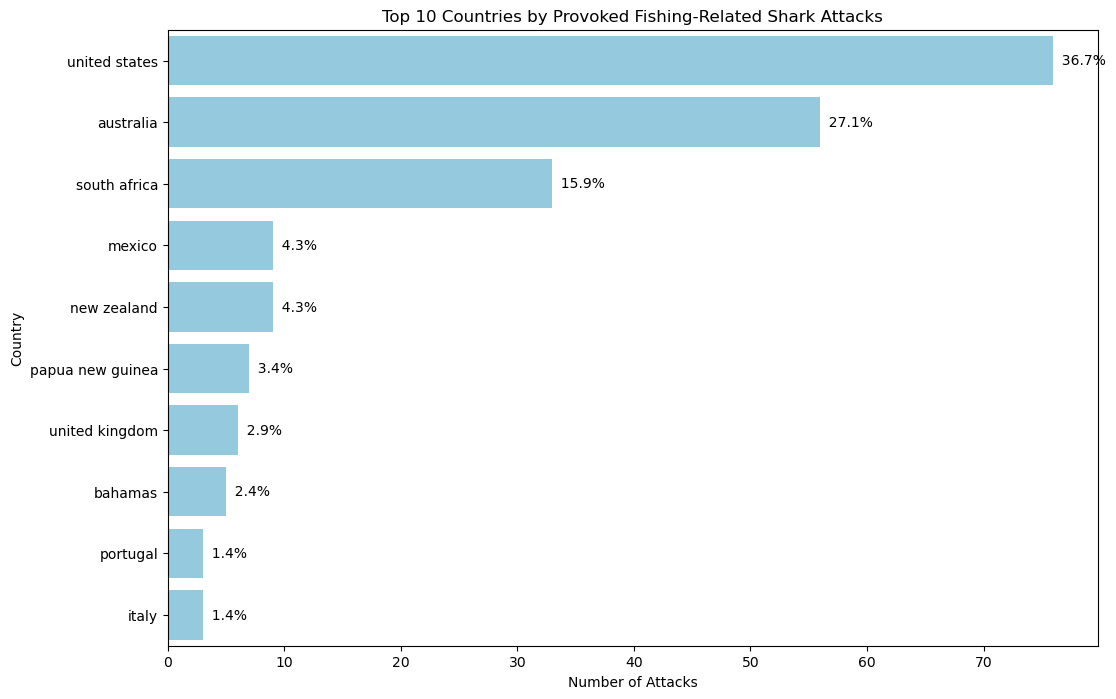

In [37]:
# Set up the figure size for the bar plot
plt.figure(figsize=(12, 8))

# Create a horizontal bar plot without a specific color palette
sns.barplot(
    data=top_10_provoked_fishing_countries,
    x='Provoked_Fishing_Attacks',
    y='Country',
    color='skyblue'  # Use a single color for all bars
)

# Add titles and labels
plt.title('Top 10 Countries by Provoked Fishing-Related Shark Attacks')
plt.xlabel('Number of Attacks')
plt.ylabel('Country')

# Percentages for the bars
total_attacks = top_10_provoked_fishing_countries['Provoked_Fishing_Attacks'].sum()
for index, value in enumerate(top_10_provoked_fishing_countries['Provoked_Fishing_Attacks']):
    percentage = f"{value / total_attacks * 100:.1f}%"
    plt.text(value, index, f'  {percentage}', va='center')

# Display the plot
plt.show()

In [38]:
countries_list = sorted(
    shark_attack_clean_df["Country"]
    .dropna()
    .unique()
    .tolist()
)

print(countries_list)

['angola', 'antigua and barbuda', 'argentina', 'aruba', 'australia', 'bahamas', 'bangladesh', 'belize', 'bermuda', 'brazil', 'cabo verde', 'canada', 'cayman islands', 'chile', 'china', 'colombia', 'comoros', 'costa rica', 'croatia', 'cuba', 'dominican republic', 'ecuador', 'egypt', 'egypt / israel', 'el salvador', 'fiji', 'france', 'french polynesia', 'grand cayman', 'greece', 'honduras', 'hong kong', 'india', 'indonesia', 'iran', 'iraq', 'ireland', 'israel', 'italy', 'jamaica', 'japan', 'jordan', 'kenya', 'liberia', 'libya', 'madagascar', 'malaysia', 'maldives', 'malta', 'marshall islands', 'mauritius', 'mexico', 'micronesia', 'montenegro', 'morocco', 'mozambique', 'namibia', 'new caledonia', 'new zealand', 'nicaragua', 'nigeria', 'norway', 'palau', 'panama', 'papua new guinea', 'philippines', 'portugal', 'puerto rico', 'russian federation', 'saint kitts and nevis', 'saint martin', 'samoa', 'saudi arabia', 'senegal', 'seychelles', 'sierra leone', 'singapore', 'solomon islands', 'somal

In [39]:
south_hemisphere = [
    'argentina', 'australia', 'brazil', 'chile',
    'fiji', 'madagascar', 'mauritius',
    'mozambique', 'namibia', 'new caledonia',
    'new zealand', 'papua new guinea',
    'south africa', 'tanzania',
    'tonga', 'uruguay', 'vanuatu'
]

In [40]:
def hemisphere(country):

    if country in south_hemisphere:
        return "South"

    return "North"

In [41]:
shark_attack_clean_df["Hemisphere"] = (
    shark_attack_clean_df["Country"]
    .apply(hemisphere)
)

In [42]:
def get_season(date, hemisphere):

    month = date.month

    if hemisphere == "North":

        if month in [12, 1, 2]:
            return "Winter"

        elif month in [3, 4, 5]:
            return "Spring"

        elif month in [6, 7, 8]:
            return "Summer"

        else:
            return "Autumn"

    elif hemisphere == "South":

        if month in [12, 1, 2]:
            return "Summer"

        elif month in [3, 4, 5]:
            return "Autumn"

        elif month in [6, 7, 8]:
            return "Winter"

        else:
            return "Spring"

In [43]:
def get_season(date, hemisphere):

    month = date.month

    if hemisphere == "North":

        if month in [12, 1, 2]:
            return "Winter"

        elif month in [3, 4, 5]:
            return "Spring"

        elif month in [6, 7, 8]:
            return "Summer"

        else:
            return "Autumn"

    elif hemisphere == "South":

        if month in [12, 1, 2]:
            return "Summer"

        elif month in [3, 4, 5]:
            return "Autumn"

        elif month in [6, 7, 8]:
            return "Winter"

        else:
            return "Spring"

In [44]:
shark_attack_clean_df["Season"] = shark_attack_clean_df.apply(
    lambda row: get_season(
        row["Date"],
        row["Hemisphere"]
    ),
    axis=1
)

In [45]:
shark_attack_clean_df["Season"].value_counts()

Season
Summer    1874
Autumn    1169
Spring     949
Winter     740
Name: count, dtype: int64

In [46]:
#Most attacks happens on summer

In [47]:
#analyze and calculate the number of provoked shark attacks related to fishing activities, grouped by season.
provoked_fishing_by_season = (
    shark_attack_clean_df[
        (shark_attack_clean_df["Type"] == "Provoked") &
        (shark_attack_clean_df["Activity_Group"] == "Fishing")
    ]
    .groupby("Season")
    .size()
)

In [48]:
shark_attack_clean_df.head()

,Date,Year,Type,Country,Activity,Sex,Injury,Fatal Y/N,specie,Date_parsed,Date_Year,Activity_Group,Contains_Fatal,shark_name,Hemisphere,Season
0,2026-01-01,2026,Unprovoked,australia,spearfishing,M,Bite wounds to the head,y,Undetermined Bull shark most likely,NaT,2026,Fishing,False,bull shark,South,Summer
1,2026-01-01,2026,Questionable,united states,surfing,M,Bite wound to the hand,n,Blue fish bite most probable,NaT,2026,Surfing,False,unknown,North,Winter
2,2026-01-01,2026,Unprovoked,australia,skindiving,M,Severe injuries both legs,y,Great White Shark,NaT,2026,Other,False,white shark,South,Summer
3,2026-01-01,2026,Unprovoked,maldives,swimming,M,Leg strpped off flesh later amputated in hospital,n,Unknown,NaT,2026,Swimming,False,unknown,North,Winter
4,2026-01-01,2026,Unprovoked,australia,surfing,M,Bite wound to R ankle,n,Bronze Whaler,NaT,2026,Surfing,False,unknown,South,Summer


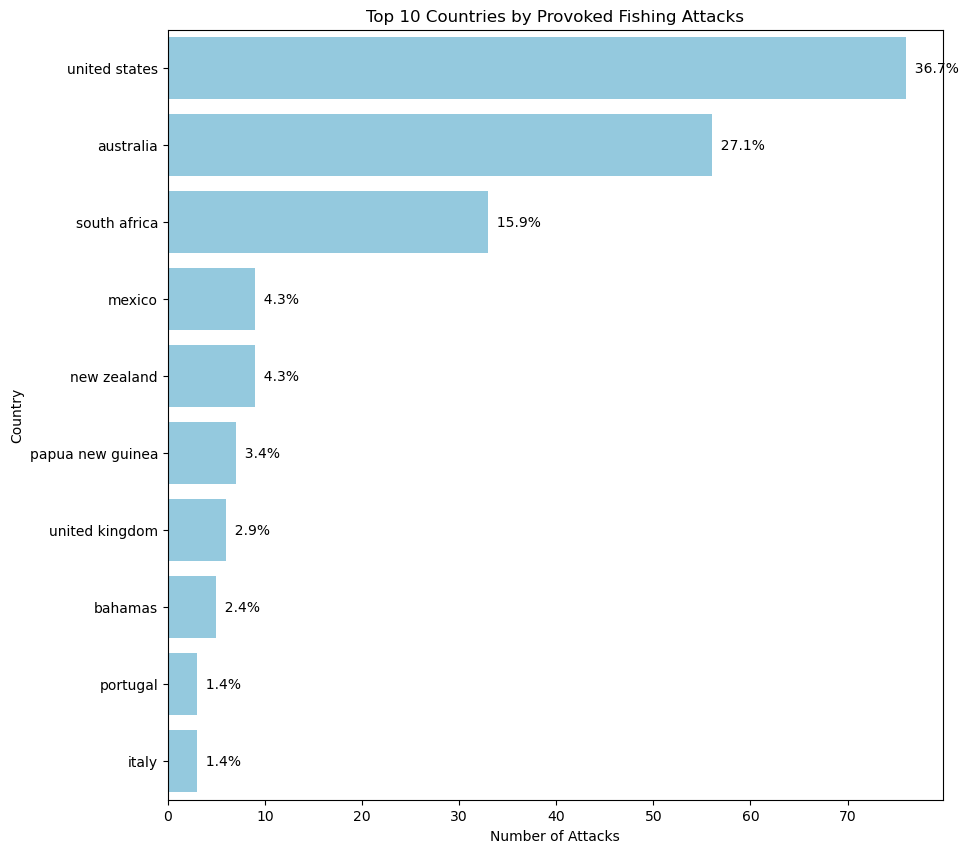

In [ ]:
#op 10 countries with the most provoked fishing-related shark attacks
plt.figure(figsize=(10, 10))

sns.barplot(
    data=top_10_provoked_fishing_countries,
    x='Provoked_Fishing_Attacks',
    y='Country',
    color='skyblue'  )

plt.title('Top 10 Countries by Provoked Fishing Attacks')
plt.xlabel('Number of Attacks')
plt.ylabel('Country')

total_attacks = top_10_provoked_fishing_countries['Provoked_Fishing_Attacks'].sum()
for index, value in enumerate(top_10_provoked_fishing_countries['Provoked_Fishing_Attacks']):
    percentage = f"{value / total_attacks * 100:.1f}%"
    plt.text(value, index, f'  {percentage}', va='center')  
plt.show()

In [ ]:
#total number of shark attacks for each country
attacks_by_country = (
    shark_attack_clean_df
    .groupby("Country")
    .size()
    .reset_index(name="Total_Attacks")
)

attacks_by_country

,Country,Total_Attacks
0,angola,1
1,antigua and barbuda,1
2,argentina,1
3,aruba,1
4,australia,892
...,...,...
96,uruguay,1
97,vanuatu,12
98,venezuela,7
99,vietnam,10


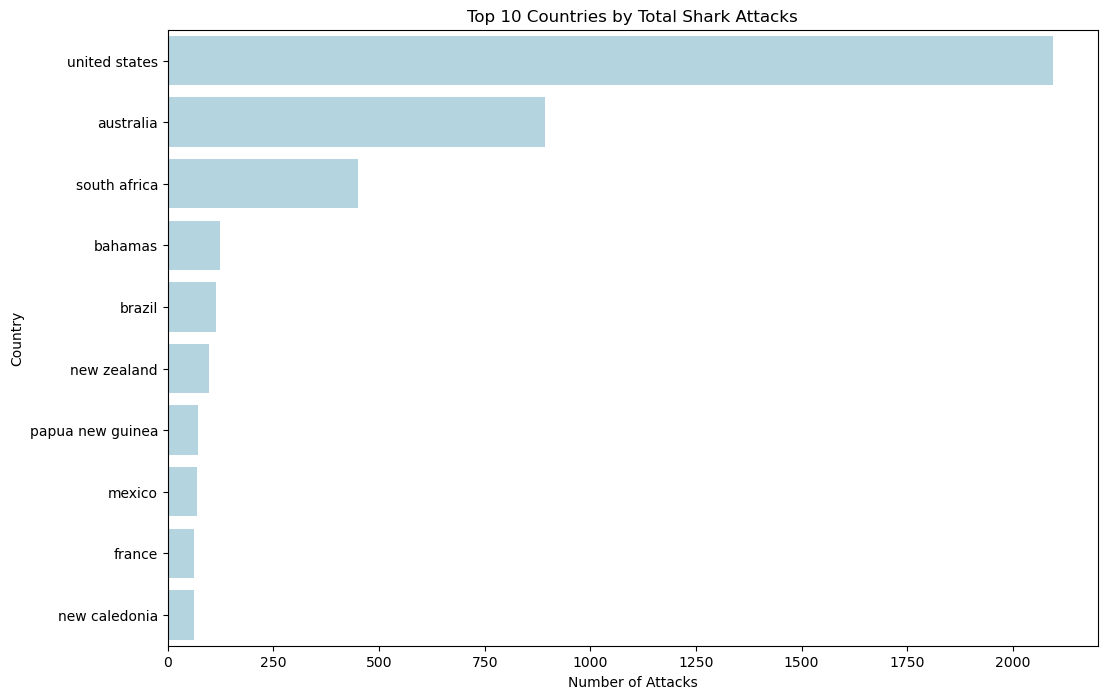

In [ ]:
#top 10 countries with the highest number of shark attacks
top_10_countries = attacks_by_country.sort_values(by="Total_Attacks", ascending=False).head(10)

plt.figure(figsize=(12, 8)) 

sns.barplot(
    data=top_10_countries,
    x="Total_Attacks",
    y="Country",
    color='lightblue'  
)

plt.title('Top 10 Countries by Total Shark Attacks')
plt.xlabel('Number of Attacks')
plt.ylabel('Country')

plt.show()

In [54]:
#calculates the frequency or count of each unique shark name in the "shark_name" column
shark_counts = shark_attack_clean_df["shark_name"].value_counts()
top_5_sharks = shark_counts.head(5)
top_5_sharks

shark_name
unknown        1902
shark           727
white shark     604
tiger shark     243
bull shark      208
Name: count, dtype: int64

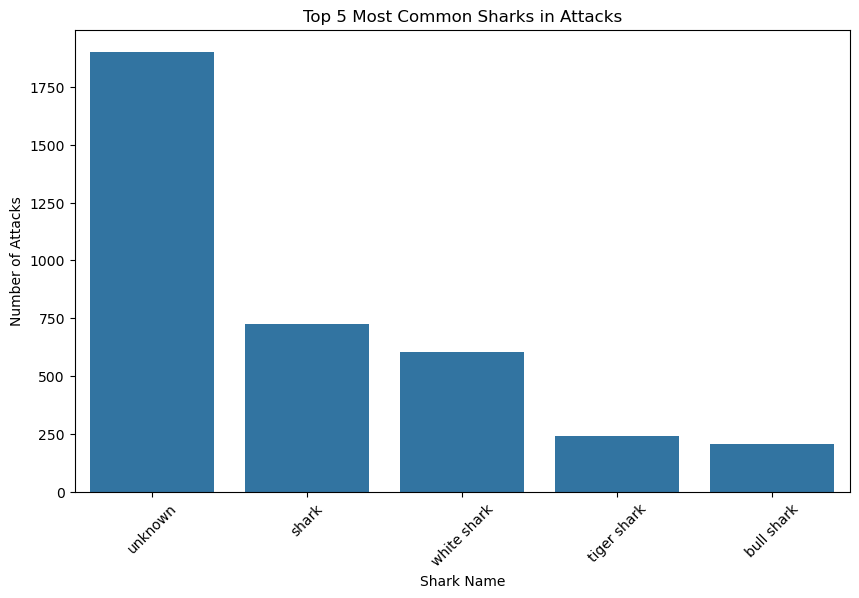

In [55]:
#op 5 most common shark names involved in attacks
top_5_df = top_5_sharks.reset_index()
top_5_df.columns = ["shark_name", "attack_count"]

# Plotting 
plt.figure(figsize=(10, 6))
sns.barplot(x="shark_name", y="attack_count", data=top_5_df)
plt.title('Top 5 Most Common Sharks in Attacks')
plt.xlabel("Shark Name")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=45)  
plt.show()

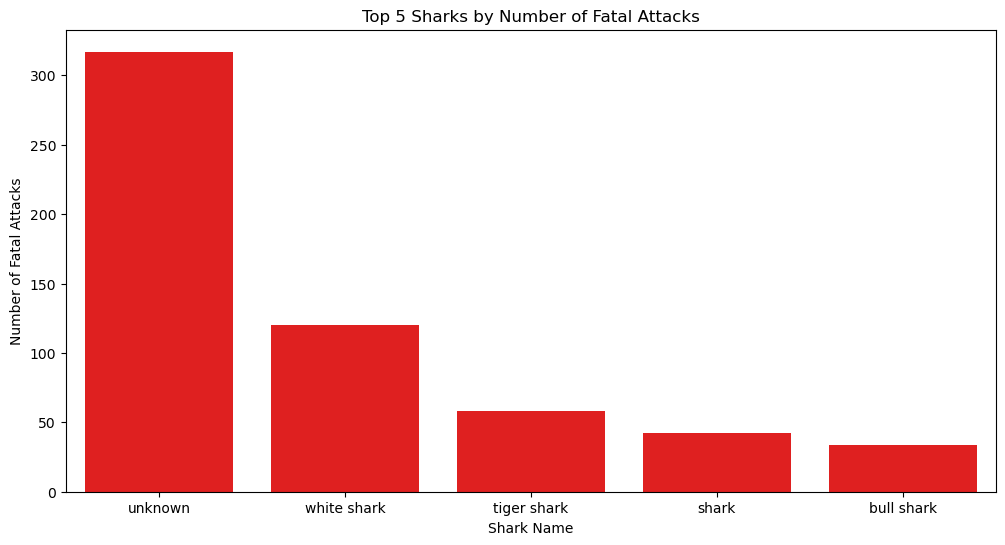

In [56]:
#visualize the top 5 shark species associated with fatal attacks
fatal_attacks = shark_attack_clean_df[shark_attack_clean_df["Fatal Y/N"] == "y"]["shark_name"].value_counts()
top_5_fatal_sharks = fatal_attacks.head(5)
fatal_df = top_5_fatal_sharks.reset_index()
fatal_df.columns = ["shark_name", "fatal_attack_count"]

plt.figure(figsize=(12, 6))
sns.barplot(x="shark_name", y="fatal_attack_count", data=fatal_df, color="red")
plt.title("Top 5 Sharks by Number of Fatal Attacks")
plt.xlabel("Shark Name")
plt.ylabel("Number of Fatal Attacks")
plt.show()

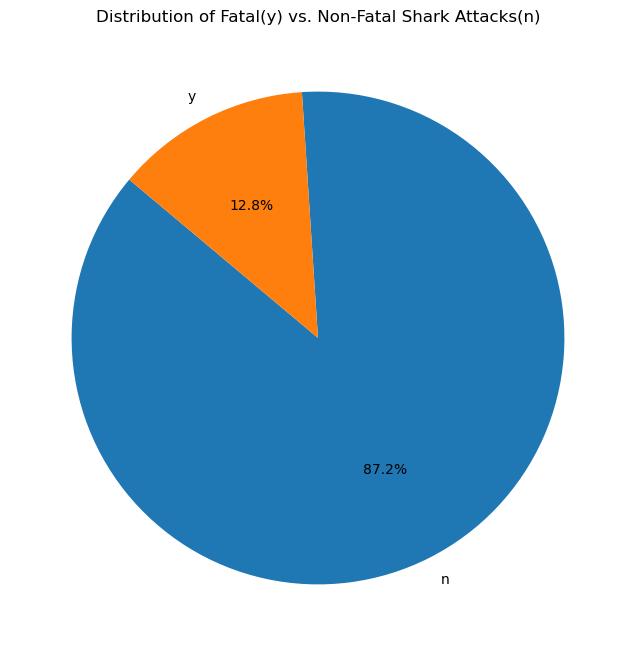

In [57]:
#visualize the distribution of fatal versus non-fatal shark attacks
categories = shark_attack_clean_df["Fatal Y/N"].value_counts() 

plt.figure(figsize=(8, 8))
plt.pie(categories, labels=categories.index, autopct="%1.1f%%", startangle=140)
plt.title("Distribution of Fatal(y) vs. Non-Fatal Shark Attacks(n)")
plt.show()